In [5]:
import pandas as pd 
df=pd.read_csv("Drug_Sales.csv")
df

,date,year,month,day,region,country,category,medicine,age_group,units_sold,unit_price,stock_level,expiry_days_remaining,covid_flag
0,2025-10-12,2025,10,12,Middle East,UAE,Chronic,Amlodipine,0-12,328,45.38,4774,466,0
1,2020-09-15,2020,9,15,South Asia,India,Chronic,Amlodipine,26-45,371,75.49,4584,181,1
2,2020-02-26,2020,2,26,Middle East,UAE,Vitamin,Vitamin C,0-12,948,22.51,3934,556,1
3,2025-11-09,2025,11,9,South Asia,Sri Lanka,Chronic,Amlodipine,0-12,275,63.29,4544,330,0
4,2022-04-04,2022,4,4,South America,Argentina,Chronic,Amlodipine,26-45,563,44.28,4284,590,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177985,2024-02-07,2024,2,7,East Asia,South Korea,Chronic,Amlodipine,46-65,298,9.51,4542,339,0
177986,2023-07-20,2023,7,20,Europe,Germany,Cough_Cold,Cough Syrup,13-25,330,32.92,4698,212,0
177987,2024-07-07,2024,7,7,Europe,France,Antipyretic,Paracetamol,26-45,225,35.20,4898,51,0
177988,2025-01-09,2025,1,9,South America,Argentina,Vitamin,Multivitamin,46-65,249,42.14,4942,704,0


In [7]:
print(df.info())
print(df.shape)
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177990 entries, 0 to 177989
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   date                   177990 non-null  object 
 1   year                   177990 non-null  int64  
 2   month                  177990 non-null  int64  
 3   day                    177990 non-null  int64  
 4   region                 177990 non-null  object 
 5   country                177990 non-null  object 
 6   category               177990 non-null  object 
 7   medicine               177990 non-null  object 
 8   age_group              177990 non-null  object 
 9   units_sold             177990 non-null  int64  
 10  unit_price             177990 non-null  float64
 11  stock_level            177990 non-null  int64  
 12  expiry_days_remaining  177990 non-null  int64  
 13  covid_flag             177990 non-null  int64  
dtypes: float64(1), int64(7), object(6)
m

In [9]:
print(df.isnull().sum())

date                     0
year                     0
month                    0
day                      0
region                   0
country                  0
category                 0
medicine                 0
age_group                0
units_sold               0
unit_price               0
stock_level              0
expiry_days_remaining    0
covid_flag               0
dtype: int64


In [11]:
print(df['medicine'].unique())

['Amlodipine' 'Vitamin C' 'Metformin' 'Azithromycin' 'Cough Syrup'
 'Amoxicillin' 'Paracetamol' 'Multivitamin' 'Cetirizine' 'Ibuprofen']


In [13]:
generic = ['Amlodipine', 'Vitamin C', 'Metformin',
           'Azithromycin', 'Amoxicillin',
           'Paracetamol', 'Cetirizine', 'Ibuprofen']

df['Medicine_Type'] = df['medicine'].apply(
    lambda x: 'Generic' if x in generic else 'Branded'
)

In [15]:
df

,date,year,month,day,region,country,category,medicine,age_group,units_sold,unit_price,stock_level,expiry_days_remaining,covid_flag,Medicine_Type
0,2025-10-12,2025,10,12,Middle East,UAE,Chronic,Amlodipine,0-12,328,45.38,4774,466,0,Generic
1,2020-09-15,2020,9,15,South Asia,India,Chronic,Amlodipine,26-45,371,75.49,4584,181,1,Generic
2,2020-02-26,2020,2,26,Middle East,UAE,Vitamin,Vitamin C,0-12,948,22.51,3934,556,1,Generic
3,2025-11-09,2025,11,9,South Asia,Sri Lanka,Chronic,Amlodipine,0-12,275,63.29,4544,330,0,Generic
4,2022-04-04,2022,4,4,South America,Argentina,Chronic,Amlodipine,26-45,563,44.28,4284,590,0,Generic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177985,2024-02-07,2024,2,7,East Asia,South Korea,Chronic,Amlodipine,46-65,298,9.51,4542,339,0,Generic
177986,2023-07-20,2023,7,20,Europe,Germany,Cough_Cold,Cough Syrup,13-25,330,32.92,4698,212,0,Branded
177987,2024-07-07,2024,7,7,Europe,France,Antipyretic,Paracetamol,26-45,225,35.20,4898,51,0,Generic
177988,2025-01-09,2025,1,9,South America,Argentina,Vitamin,Multivitamin,46-65,249,42.14,4942,704,0,Branded


In [17]:
#Top-Selling Medicines

top_medicines = df.groupby('medicine')['units_sold'].sum().sort_values(ascending=False)
print(top_medicines)

medicine
Azithromycin    8020301
Paracetamol     8017852
Ibuprofen       7987183
Multivitamin    7986884
Metformin       7982576
Vitamin C       7973727
Cough Syrup     7956059
Amlodipine      7952510
Cetirizine      7939871
Amoxicillin     7907223
Name: units_sold, dtype: int64


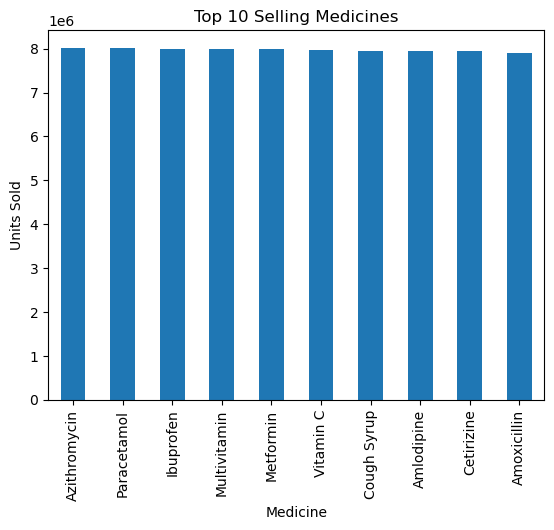

In [19]:
import matplotlib.pyplot as plt

top_medicines.plot(kind='bar')
plt.title("Top 10 Selling Medicines")
plt.xlabel("Medicine")
plt.ylabel("Units Sold")
plt.show()

In [21]:
df['Revenue'] = df['units_sold'] * df['unit_price']
df

,date,year,month,day,region,country,category,medicine,age_group,units_sold,unit_price,stock_level,expiry_days_remaining,covid_flag,Medicine_Type,Revenue
0,2025-10-12,2025,10,12,Middle East,UAE,Chronic,Amlodipine,0-12,328,45.38,4774,466,0,Generic,14884.64
1,2020-09-15,2020,9,15,South Asia,India,Chronic,Amlodipine,26-45,371,75.49,4584,181,1,Generic,28006.79
2,2020-02-26,2020,2,26,Middle East,UAE,Vitamin,Vitamin C,0-12,948,22.51,3934,556,1,Generic,21339.48
3,2025-11-09,2025,11,9,South Asia,Sri Lanka,Chronic,Amlodipine,0-12,275,63.29,4544,330,0,Generic,17404.75
4,2022-04-04,2022,4,4,South America,Argentina,Chronic,Amlodipine,26-45,563,44.28,4284,590,0,Generic,24929.64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177985,2024-02-07,2024,2,7,East Asia,South Korea,Chronic,Amlodipine,46-65,298,9.51,4542,339,0,Generic,2833.98
177986,2023-07-20,2023,7,20,Europe,Germany,Cough_Cold,Cough Syrup,13-25,330,32.92,4698,212,0,Branded,10863.60
177987,2024-07-07,2024,7,7,Europe,France,Antipyretic,Paracetamol,26-45,225,35.20,4898,51,0,Generic,7920.00
177988,2025-01-09,2025,1,9,South America,Argentina,Vitamin,Multivitamin,46-65,249,42.14,4942,704,0,Branded,10492.86


In [23]:
revenue = df.groupby('medicine')['Revenue'].sum().sort_values(ascending=False)
print(revenue)

medicine
Paracetamol     4.240456e+08
Azithromycin    4.234614e+08
Cough Syrup     4.217521e+08
Multivitamin    4.195847e+08
Ibuprofen       4.188885e+08
Metformin       4.187263e+08
Cetirizine      4.177555e+08
Amoxicillin     4.159629e+08
Amlodipine      4.156388e+08
Vitamin C       4.149965e+08
Name: Revenue, dtype: float64


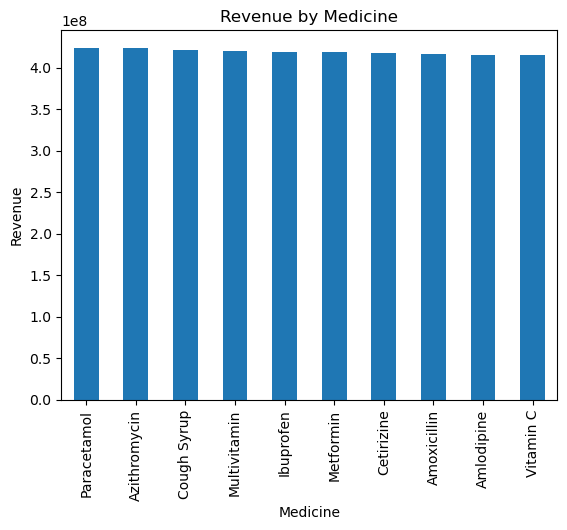

In [25]:
revenue.plot(kind='bar')
plt.title('Revenue by Medicine')
plt.xlabel('Medicine')
plt.ylabel('Revenue')
plt.show()

In [23]:
#Monthly Sales Growth

monthly_sales = df.groupby('month')['Revenue'].sum().sort_index()
monthly_sales

month
1     4.186670e+08
2     4.266197e+08
3     4.742019e+08
4     4.550786e+08
5     4.161068e+08
6     3.501079e+08
7     2.957001e+08
8     2.473737e+08
9     2.255807e+08
10    2.478234e+08
11    2.834533e+08
12    3.500992e+08
Name: Revenue, dtype: float64

In [34]:
monthly_growth = monthly_sales.pct_change() * 100
print(monthly_growth)

month
1           NaN
2      1.899543
3     11.153314
4     -4.032735
5     -8.563764
6    -15.861044
7    -15.540295
8    -16.343061
9     -8.809734
10     9.860202
11    14.377124
12    23.512127
Name: Revenue, dtype: float64


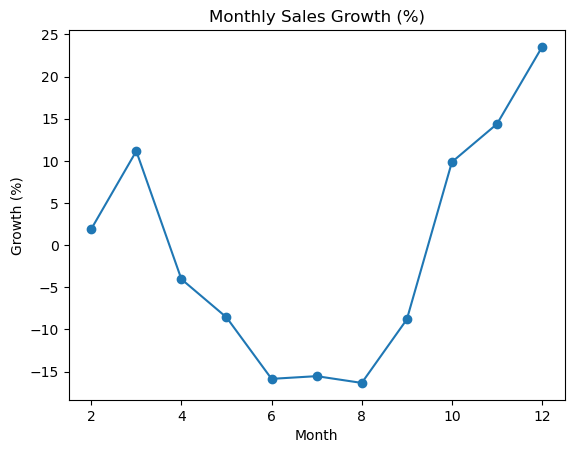

In [36]:
monthly_growth.plot(marker='o')
plt.title('Monthly Sales Growth (%)')
plt.xlabel('Month')
plt.ylabel('Growth (%)')
plt.show()

In [38]:
# Total units sold per month
monthly_units = df.groupby('month')['units_sold'].sum()
print(monthly_units)

month
1     7970454
2     8056917
3     9129266
4     8616463
5     7897499
6     6612286
7     5586378
8     4702189
9     4276707
10    4713159
11    5411660
12    6751208
Name: units_sold, dtype: int64


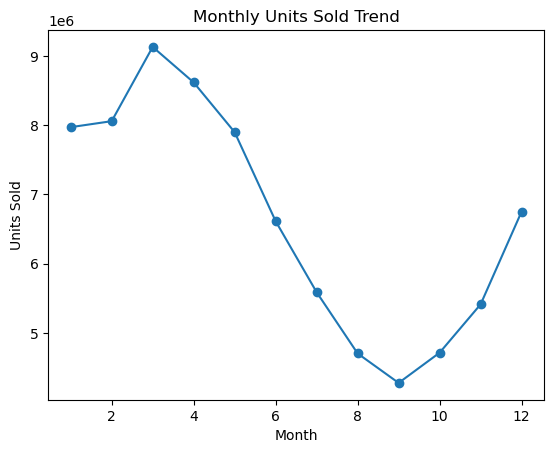

In [40]:
monthly_units.plot(kind='line', marker='o')
plt.title('Monthly Units Sold Trend')
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.show()

In [44]:
region_sales = df.groupby('region')['units_sold'].sum()
region_sales

region
Africa            9879220
East Asia        10019811
Europe            9931014
Middle East      10001814
North America     9931812
Oceania          10001961
South America     9985310
South Asia        9973244
Name: units_sold, dtype: int64

In [48]:
region_sales = df.groupby('region')['Revenue'].sum()
region_sales

region
Africa           5.204328e+08
East Asia        5.292539e+08
Europe           5.241345e+08
Middle East      5.239983e+08
North America    5.220569e+08
Oceania          5.235241e+08
South America    5.267808e+08
South Asia       5.206311e+08
Name: Revenue, dtype: float64

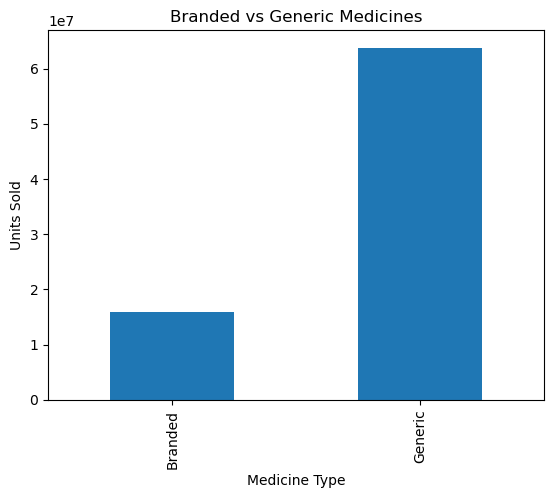

In [27]:
brand_generic = df.groupby('Medicine_Type')['units_sold'].sum()

brand_generic.plot(kind='bar')
plt.title('Branded vs Generic Medicines')
plt.xlabel('Medicine Type')
plt.ylabel('Units Sold')
plt.show()

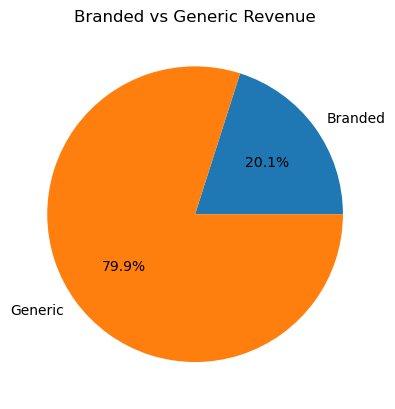

In [29]:
brand_revenue = df.groupby('Medicine_Type')['Revenue'].sum()

brand_revenue.plot(kind='pie', autopct='%1.1f%%')
plt.title('Branded vs Generic Revenue')
plt.ylabel('')
plt.show()